# Confidence interval visualization

The following script demonstrates a random selection of data from a population, drawing a single vertical line that represents a confidence interval with a black dot representing the mean for that selection. This is repeated 100 times, with a red line representing selections that did not include the population mean in within its confidence interval.

# 信頼区間の可視化

以下のスクリプトは、母集団からデータをランダムに選択し、選択されたデータの平均を黒い点で示し、その信頼区間を垂直線で描画します。これを100回繰り返し、母集団の平均が信頼区間に含まれなかった選択を赤い線で示します。

In [1]:
# ライブラリが未インストールの場合に備えてインストール（Google Colab 用）
%pip install matplotlib seaborn pandas numpy scipy --quiet


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 必要なライブラリをインポート
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from scipy.stats import t
import random

# 日本語フォントの設定（macOS や Google Colab でも使えるものを指定）
matplotlib.rcParams['font.family'] = 'Hiragino Sans'  # macOS / Colab
# matplotlib.rcParams['font.family'] = 'MS Gothic'    # Windows の場合はこちらを使用


In [4]:
def tie(population_mean=50, population_size=100000, scale=10, sample_size=10, num_samples=1, confidence_coefficient=0.95):
    # パラメータ
    # population_mean = 50  # 母集団の平均
    # population_size = 100000  # 母集団のサイズ
    # sample_size = 10  # サンプルのサイズ
    # num_samples = 100  # サンプルの数
    # confidence_coefficient = 0.95  # 信頼係数

    # 正規分布に従う母集団を生成
    population = np.random.normal(loc=population_mean, size=population_size,scale=scale)
    # サンプル平均と信頼区間を格納するための配列を初期化
    sample_means = np.zeros(num_samples)
    confidence_intervals = np.zeros((2, num_samples))

    # グラフの幅を100%に設定
    plt.figure(figsize=(15, 6))

    # サンプルを生成し、サンプル平均と信頼区間を計算
    for i in range(num_samples):
        # 母集団からランダムにサンプルを選択
        sample = np.random.choice(population, size=sample_size)
        
        # サンプルの平均と標準偏差を計算
        sample_mean = np.mean(sample)
        sample_std_dev = np.std(sample)
        
        # サンプル平均を格納
        sample_means[i] = sample_mean
        
        # 平均の標準誤差を計算
        sem = sample_std_dev / np.sqrt(sample_size)
        
        # 自由度を計算
        degrees_of_freedom = sample_size - 1
        
        # 与えられた信頼係数と自由度に対するt値を計算
        t_value = stats.t.ppf((1 + confidence_coefficient) / 2, degrees_of_freedom)
        
        # 信頼区間を計算
        confidence_interval = [sample_mean - t_value * sem, sample_mean + t_value * sem]
        confidence_intervals[:, i] = confidence_interval
        
        # サンプルを垂直線としてプロットし、その中心に平均を表示
        if population_mean < confidence_interval[0] or population_mean > confidence_interval[1]:
            plt.plot([i, i], [confidence_interval[0], confidence_interval[1]], color='red')
        else:
            plt.plot([i, i], [confidence_interval[0], confidence_interval[1]], color='blue')
        plt.plot(i, sample_mean, 'ko')

    # 母集団の平均を水平線としてプロット
    plt.axhline(y=population_mean, color='green', linestyle='--', label='母集団の平均')

    # プロットのラベルとタイトルを設定
    plt.xlabel('サンプルインデックス')
    plt.ylabel('サンプル平均')
    plt.title('信頼区間付きのサンプル平均', fontsize=25,pad=20)

    # set the y-axis limits
    plt.ylim([population_mean - 30, population_mean + 30])

    #　凡例を表示
    plt.legend()

    # グラフを表示
    plt.show()

    # print the number of times the population mean was within the confidence interval
    num_within_interval = np.sum((confidence_intervals[0, :] < population_mean) & (confidence_intervals[1, :] > population_mean))   
    print(f'母集団の平均が信頼区間内にある回数: {num_within_interval} / {num_samples}')

    # print the average width of the confidence interval and the average sample mean
    average_width = np.mean(confidence_intervals[1, :] - confidence_intervals[0, :])
    average_sample_mean = np.mean(sample_means)

    # round the values to two decimal places
    average_width = np.round(average_width, 2)
    average_sample_mean = np.round(average_sample_mean, 2)
    
    print(f'信頼区間の平均幅: {average_width}')
    print(f'サンプル平均の平均: {average_sample_mean}')



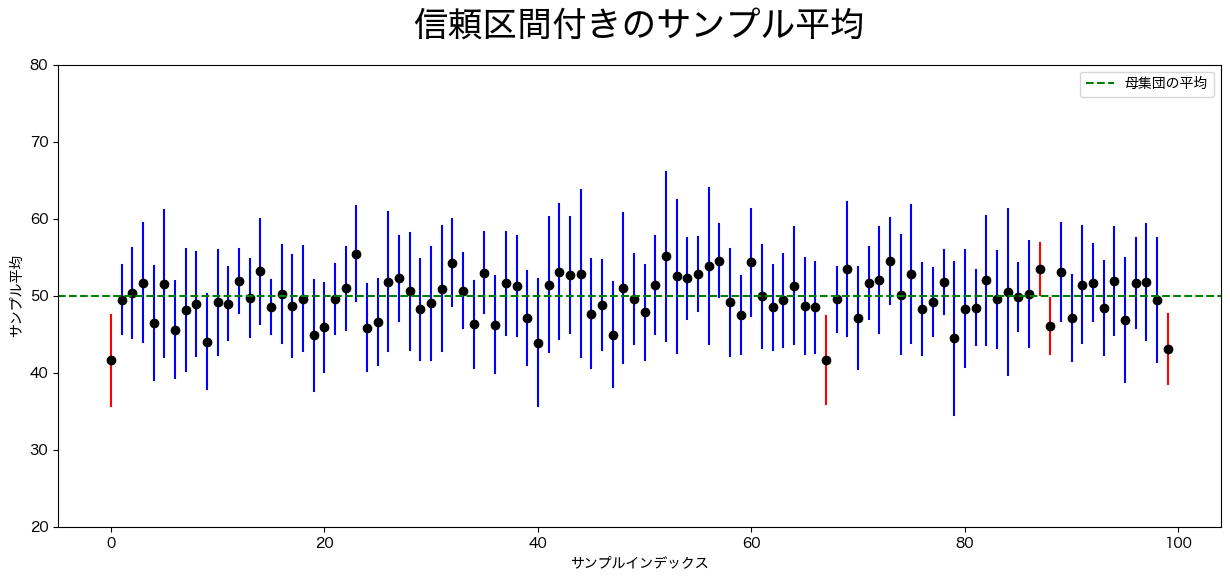

母集団の平均が信頼区間内にある回数: 95 / 100
信頼区間の平均幅: 13.13
サンプル平均の平均: 49.75


In [27]:
tie(population_mean=50, 
    population_size=100000,
    scale=10, 
    sample_size=10, 
    num_samples=100, 
    confidence_coefficient=0.95)

# Sushida🍣

Enter your scores [here](https://docs.google.com/spreadsheets/d/1vwu8iJ-u8NZ-f6UoNJEo80q3uMiujRQzzBD-VhjLXYo/edit?gid=1063303064#gid=1063303064)

In [ ]:
# ライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt

# データを読み込む
file_path = 'sushida.csv'  # ファイルパスを必要に応じて調整
data = pd.read_csv(file_path)

# 可視化のために必要なデータを抽出
group_labels = data['標本']
group_means = data['Sample mean']
lower_bounds = data['Lower bound']
upper_bounds = data['Upper bound']

# グループ平均から全体の母集団平均を計算
overall_population_mean = group_means.mean()

# グループ信頼区間の可視化
plt.figure(figsize=(12, 6))

# グループ信頼区間を線としてプロットし、平均を点として表示
for i, (mean, lower, upper) in enumerate(zip(group_means, lower_bounds, upper_bounds)):
    plt.plot([i, i], [lower, upper], color='blue', linestyle='-', linewidth=2)  # 信頼区間の線
    plt.scatter(i, mean, color='red', s=50, label="Group Mean" if i == 0 else "")  # 平均の点

# 全体の母集団平均を基準線としてプロット
plt.axhline(overall_population_mean, color='green', linestyle='--', label=f"Overall Population Mean = {overall_population_mean:.2f}")

# プロットのフォーマット設定
plt.title("Group Confidence Intervals Around Overall Population Mean")
plt.xlabel("Groups")
plt.ylabel("Yen Earned")
plt.xticks(range(len(group_labels)), group_labels, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
# students
students = ["Yoh","soichi","souta","Iori","Kotaro","Raito","ryoya","Takuya","You","hiroya","Koki","kakeru","youhei","akira","Eiji","Yuma","aoi","kieto","takahiro","Shotaro","Kazuhiro","Souta","Hayato","tatsuki","Kota","Rikuya","Ogawa","Riku","Ryusei"]

# scores

scores = [1580,-540,3000,980,60,-120,1980,1200,-540,-780,1880,-780,1980,1880,-1560,728,-300,2820,-300,1780,-1200,1280,880,-120,-560,-360,-1440,780,1880]

# # if simulating, randomize the scores
# count = len(students)

# # scores
# np.random.seed(42)
# scores = np.random.randint(0, 101, size=count)

data = pd.DataFrame({
    'Student': students,
    'Score': scores
})

data

,Student,Score
0,Yoh,1580
1,soichi,-540
2,souta,3000
3,Iori,980
4,Kotaro,60
5,Raito,-120
6,ryoya,1980
7,Takuya,1200
8,You,-540
9,hiroya,-780


In [29]:
# with this data, divide students into random groups of 5

group_size = 5
shuffled_data = data.sample(frac=1).reset_index(drop=True)
num_groups = len(shuffled_data) // group_size
groups = [shuffled_data.iloc[i*group_size:(i+1)*group_size] for i in range(num_groups)]     
for i, group in enumerate(groups):
    print(f"Group {i+1}:\n{group}\n")



Group 1:
   Student  Score
0   soichi   -540
1    Ogawa  -1440
2  Shotaro   1780
3     Iori    980
4   Takuya   1200

Group 2:
    Student  Score
5     ryoya   1980
6     akira   1880
7    youhei   1980
8      Koki   1880
9  Kazuhiro  -1200

Group 3:
   Student  Score
10  kakeru   -780
11    Riku    780
12  Rikuya   -360
13   Raito   -120
14  Hayato    880

Group 4:
   Student  Score
15     You   -540
16  hiroya   -780
17  Kotaro     60
18   kieto   2820
19    Yuma    728

Group 5:
     Student  Score
20  takahiro   -300
21    Ryusei   1880
22     Souta   1280
23       Yoh   1580
24   tatsuki   -120



In [30]:
groups

[   Student  Score
 0   soichi   -540
 1    Ogawa  -1440
 2  Shotaro   1780
 3     Iori    980
 4   Takuya   1200,
     Student  Score
 5     ryoya   1980
 6     akira   1880
 7    youhei   1980
 8      Koki   1880
 9  Kazuhiro  -1200,
    Student  Score
 10  kakeru   -780
 11    Riku    780
 12  Rikuya   -360
 13   Raito   -120
 14  Hayato    880,
    Student  Score
 15     You   -540
 16  hiroya   -780
 17  Kotaro     60
 18   kieto   2820
 19    Yuma    728,
      Student  Score
 20  takahiro   -300
 21    Ryusei   1880
 22     Souta   1280
 23       Yoh   1580
 24   tatsuki   -120]

['Yoh', 'soichi', 'souta', 'Iori', 'Kotaro', 'Raito', 'ryoya', 'Takuya', 'You', 'hiroya', 'Koki', 'kakeru', 'youhei', 'akira', 'Eiji', 'Yuma', 'aoi', 'kieto', 'takahiro', 'Shotaro', 'Kazuhiro', 'Souta', 'Hayato', 'tatsuki', 'Kota', 'Rikuya', 'Ogawa', 'Riku', 'Ryusei']
[1580, -540, 3000, 980, 60, -120, 1980, 1200, -540, -780, 1880, -780, 1980, 1880, -1560, 728, -300, 2820, -300, 1780, -1200, 1280, 880, -120, -560, -360, -1440, 780, 1880]


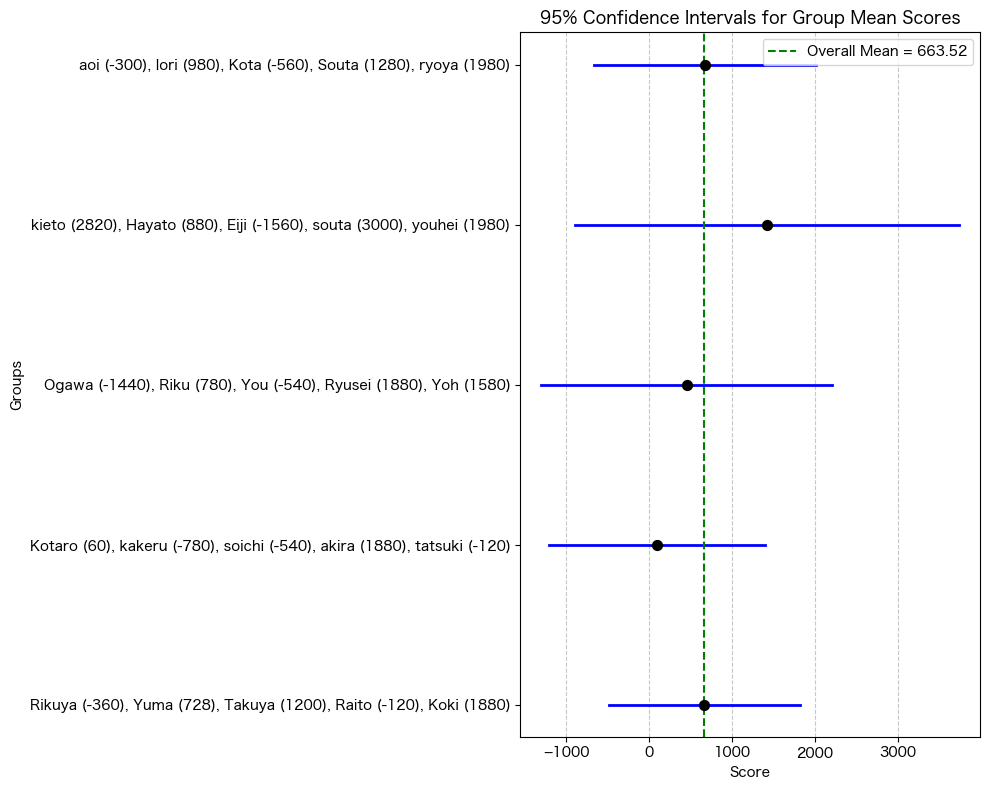

In [31]:
# Prepare a clean version of the script that uses copy-pasteable `students` and `scores` input

# # Example placeholder data for students and their corresponding scores
# students = [
#     "Takuya", "Kazuhiro", "Ayuma", "Shoutarou", "Shion",
#     "Akira", "Hayato", "Aiwa", "Youhei", "Tuankiet",
#     "Riku", "Kousei", "Raimu", "Souta", "Hiromu",
#     "Keigo", "Kotarou", "Shunto", "Ryouya", "Aoi",
#     "Eiji", "Raito", "Takahiro", "Jiaxiang", "Yuukyou",
#     "Rikuya", "Mishou", "Tatuki", "Akira", "Iori",
#     "Souta", "Souichirou", "Kotarou", "Ryusei", "Yusuke"
# ]

# # Generate example scores for each student as integers
# scores = np.random.normal(loc=50, scale=10, size=len(students)).astype(int)

print(students)
print(scores)

# Group students into random groups of 5
group_size = 5
shuffled_data = pd.DataFrame({
    'Student': students,
    'Score': scores
}).sample(frac=1).reset_index(drop=True)
num_groups = len(shuffled_data) // group_size
groups = [shuffled_data.iloc[i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Calculate overall mean
all_scores = np.concatenate([group['Score'] for group in groups])
overall_mean = np.mean(all_scores)

# Plot
plt.figure(figsize=(10, 8))

for i, group in enumerate(groups):
    group_scores = group['Score']
    group_mean = np.mean(group_scores)
    group_std = np.std(group_scores, ddof=1)
    n = len(group_scores)
    sem = group_std / np.sqrt(n)
    t_value = stats.t.ppf(0.975, n - 1)
    margin = t_value * sem
    lower = group_mean - margin
    upper = group_mean + margin

    # Color based on whether CI contains overall mean
    color = 'blue' if lower <= overall_mean <= upper else 'red'

    # Plot CI and mean
    plt.plot([lower, upper], [i, i], color=color, linewidth=2)
    plt.scatter(group_mean, i, color='black', s=50, zorder=5)

# Overall mean line
plt.axvline(overall_mean, color='green', linestyle='--', label=f'Overall Mean = {overall_mean:.2f}')

# Y-axis group labels
# add the student names as labels with their scores in parentheses after each name
yticks = [', '.join([f"{name} ({score:.0f})" for name, score in zip(group['Student'], group['Score'])]) for group in groups]

plt.yticks(ticks=range(len(groups)), labels=yticks)

# Final formatting
plt.title('95% Confidence Intervals for Group Mean Scores')
plt.xlabel('Score')
plt.ylabel('Groups')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 鞄鞄🎒

In [32]:
def backpacks(
    sample_size=10, 
    population_low=5.0, 
    population_high=7.0, 
    confidence_level=0.95
):
    import numpy as np
    import matplotlib.pyplot as plt
    import random
    from scipy.stats import t
    import pandas as pd

    # 学生のリスト
    students = [
        "Yoh","soichi","souta","Iori","Kotaro","Raito","ryoya","Takuya","You","hiroya","Koki","kakeru","youhei","akira","Eiji","Yuma","aoi","kieto","takahiro","Shotaro","Kazuhiro","Souta","Hayato","tatsuki","Kota","Rikuya","Ogawa","Riku","Ryusei"
    ]

    # 母集団の重さをシミュレート
    np.random.seed(42)
    population_weights = np.random.uniform(population_low, population_high, len(students))
    population_mean = np.mean(population_weights)

    # サンプル抽出
    sample_indices = random.sample(range(len(students)), sample_size)
    sample_weights = population_weights[sample_indices]
    sample_students = [students[i] for i in sample_indices]

    # 統計量の計算
    x_bar = np.mean(sample_weights)
    sample_variance = np.var(sample_weights, ddof=1)
    df = sample_size - 1
    t_critical = t.ppf(confidence_level, df)
    margin_of_error = t_critical * np.sqrt(sample_variance / sample_size)
    confidence_interval = (x_bar - margin_of_error, x_bar + margin_of_error)

    # 丸める
    sample_weights = sample_weights.round(1)
    x_bar_rounded = round(x_bar, 1)
    confidence_interval_rounded = (round(confidence_interval[0], 1), round(confidence_interval[1], 1))
    population_mean = round(population_mean, 1)

    # 出力
    print("母集団の平均:")
    print(population_mean)

    print("\nサンプリングされた学生とリュックの重さ:")
    print(pd.DataFrame({
        "学生": sample_students,
        "サンプルの重さ (kg)": sample_weights
    }))

    print("\nサンプルの平均と信頼区間:")
    print(pd.DataFrame({
        "メトリック": ["サンプルの平均", "サンプルの信頼区間"],
        "値": [x_bar_rounded, confidence_interval_rounded]
    }))

    # グラフ描画
    plt.figure(figsize=(10, 6))
    plt.axhline(population_mean, color='blue', linestyle='--', label=f'母集団の平均 ({population_mean} kg)')
    plt.errorbar(1, x_bar, yerr=margin_of_error, fmt='o', color='red', label='サンプル平均と信頼区間')
    plt.scatter(range(len(sample_weights)), sample_weights, color='green', label='サンプルの重さ')

    for i, (student, weight) in enumerate(zip(sample_students, sample_weights)):
        plt.annotate(f"{student} ({weight} kg)", (i, weight), textcoords="offset points", xytext=(0, 5), ha='center')

    plt.title("サンプルの信頼区間と母集団の平均")
    plt.xlabel("サンプリングされた学生")
    plt.ylabel("リュックの重さ (kg)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


母集団の平均:
5.9

サンプリングされた学生とリュックの重さ:
       学生  サンプルの重さ (kg)
0    Iori           6.2
1     Yoh           5.7
2   kieto           6.0
3     You           6.2
4  Rikuya           6.6

サンプルの平均と信頼区間:
       メトリック           値
0    サンプルの平均         6.2
1  サンプルの信頼区間  (5.9, 6.4)


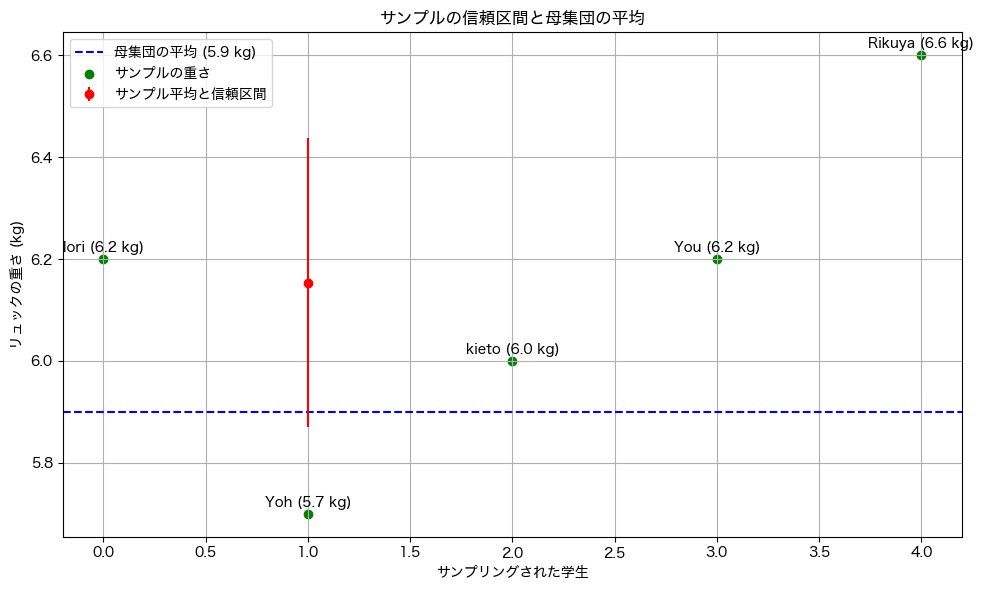

In [49]:
backpacks(sample_size=5, 
          population_low=5.0, 
          population_high=7.0, 
          confidence_level=0.95)